In [1]:
import json
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Stage 1: Load Dataset and Ground Truth 
# ---------------------------------------------------------
dataset = load_dataset("pubmed_qa", "pqa_labeled")
with open('test_ground_truth.json', 'r') as f:
    ground_truth = json.load(f)
test_ids = set(ground_truth.keys()) 

In [3]:
# Stage 2: Split into Official Test and Development Sets
# ---------------------------------------------------------
dev = []
test = []
maping = {"no": 0, "maybe": 1, "yes": 2}
for row in dataset['train']:
    Id = str(row['pubid']) 
    data = {'text': f"[QUESTION]: {row['question']} [CONTEXT]: {' '.join(row['context']['contexts'])}", 
                  'label': maping[row['final_decision']]}
    if Id in test_ids: test.append(data)
    else: dev.append(data)

df_dev = pd.DataFrame(dev)
df_test = pd.DataFrame(test)
X_dev, y_dev = df_dev['text'], df_dev['label']
X_test, y_test = df_test['text'], df_test['label']

In [4]:
# Stage 3: Classification
# ---------------------------------------------------------

kf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
probs = []

for f, (tr, va) in enumerate(kf.split(X_dev, y_dev)):
    X_train, X_val = X_dev.iloc[tr], X_dev.iloc[va]
    y_train, y_val = y_dev.iloc[tr], y_dev.iloc[va]

    cv = CountVectorizer(stop_words = 'english')
    X_trainCV = cv.fit_transform(X_train)
    X_valCV = cv.transform(X_val)

    lr = LogisticRegression(class_weight = 'balanced')
    lr.fit(X_trainCV, y_train)
    y_pred = lr.predict(X_valCV)

    X_testCV = cv.transform(X_test)
    t_probs = lr.predict_proba(X_testCV)
    probs.append(t_probs)

preds = np.argmax(np.mean(probs, axis=0), axis = 1)


Test Acuracy: 0.50
Test F1: 0.33


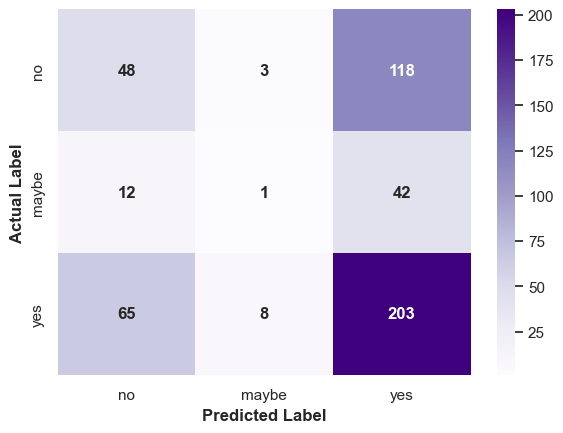

In [5]:
# Stage 4: Evaluation
# ---------------------------------------------------------
print(f"Test Acuracy: {accuracy_score(y_test, preds):.2f}")
print(f"Test F1: {f1_score( y_test,preds, average= 'macro' ):.2f}")

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4.5))
sns.set_theme(style="white")
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples', 
            xticklabels = ["no", "maybe", "yes"], 
            yticklabels = ["no", "maybe", "yes"],
            annot_kws={'weight': 'bold'})

plt.ylabel('Actual Label', fontsize = 12, fontweight = 'bold')
plt.xlabel('Predicted Label', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()